# Análise Exploratória — Censo Escolar × IDEB (2019, 2021 e 2023)

Este notebook apresenta uma nova análise exploratória das bases utilizadas no projeto, agora com o recorte temporal definido para as primeiras aplicações: **2019, 2021 e 2023**.

O objetivo é:

- caracterizar as duas fontes;
- verificar dimensão, cobertura temporal e distribuição geográfica;
- avaliar valores ausentes e duplicidades;
- identificar códigos especiais;
- analisar a distribuição do IDEB;
- validar a chave de integração;
- cruzar Censo Escolar e IDEB;
- explorar associações entre características escolares e IDEB;
- preparar atributos derivados para análises posteriores.

As primeiras 1.000 linhas são utilizadas apenas para inspeção técnica. As verificações de qualidade e as estatísticas principais são calculadas sobre as bases completas.


## 1. Importação das bibliotecas


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:.2f}")


## 2. Inspeção inicial das primeiras 1.000 linhas

A inspeção inicial permite verificar rapidamente a estrutura dos arquivos antes de carregar as bases completas. Como os arquivos podem estar ordenados, essas 1.000 linhas não devem ser interpretadas como uma amostra estatisticamente representativa.


In [3]:
censo_amostra = pd.read_csv(
    "../data/censo_nordeste_2019+.csv",
    nrows=1000,
    low_memory=False
)

ideb_amostra = pd.read_csv(
    "../data/ideb_nordeste_2019+.csv",
    nrows=1000,
    low_memory=False
)

print("Censo Escolar - amostra:", censo_amostra.shape)
print("IDEB - amostra:", ideb_amostra.shape)


Censo Escolar - amostra: (1000, 49)
IDEB - amostra: (1000, 14)


In [4]:
print("Distribuição temporal nas primeiras 1.000 linhas do Censo:")
display(censo_amostra["ano"].value_counts().sort_index().to_frame("registros"))

print("\nDistribuição temporal nas primeiras 1.000 linhas do IDEB:")
display(ideb_amostra["ano"].value_counts().sort_index().to_frame("registros"))


Distribuição temporal nas primeiras 1.000 linhas do Censo:


,registros
ano,
2021,1000



Distribuição temporal nas primeiras 1.000 linhas do IDEB:


,registros
ano,
2019,507
2021,169
2023,324


In [5]:
censo_amostra.head()


,ano,sigla_uf,id_municipio,id_municipio_nome,id_escola,rede,tipo_localizacao,agua_potavel,agua_rede_publica,energia_rede_publica,esgoto_rede_publica,lixo_servico_coleta,area_verde,banheiro_chuveiro,biblioteca,cozinha,dormitorio_aluno,laboratorio_ciencias,laboratorio_informatica,laboratorio_educacao_profissional,quadra_esportes,refeitorio,sala_leitura,quantidade_sala_utilizada_climatizada,desktop_aluno,internet_alunos,quantidade_profissional_saude,quantidade_profissional_nutricionista,quantidade_profissional_psicologo,quantidade_profissional_pedagogia,profissional_assistente_social,alimentacao,material_pedagogico_multimidia,material_pedagogico_infantil,material_pedagogico_cientifico,material_pedagogico_musical,material_pedagogico_artistica,orgao_gremio_estudantil,diurno,noturno,quantidade_matricula_feminino,quantidade_matricula_masculino,quantidade_matricula_nao_declarada,quantidade_matricula_branca,quantidade_matricula_preta,quantidade_matricula_parda,quantidade_matricula_amarela,quantidade_matricula_indigena,quantidade_matricula_utiliza_transporte_publico
0,2021,AL,2700300,Arapiraca,27053431,Privada,Urbana,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,NaN,1.00,0.00,0.00,0.00,1.00,1.00,1.00,0.00,1.00,3.00,0.00,1.00,1.00,1.00,1.00,1.00,1.00,0.00,1.00,0.00,423.00,433.00,302.00,300.00,6.00,245.00,2.00,1.00,NaN
1,2021,AL,2704302,Maceió,27226115,Privada,Urbana,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,0.00,1.00,1.00,NaN,1.00,1.00,0.00,44.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00,1.00,1.00,1.00,0.00,1.00,0.00,648.00,607.00,733.00,340.00,6.00,175.00,1.00,0.00,NaN
2,2021,AL,2709301,União dos Palmares,27024075,Privada,Urbana,1.00,1.00,1.00,1.00,1.00,0.00,1.00,1.00,1.00,0.00,0.00,1.00,NaN,1.00,0.00,0.00,16.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00,0.00,249.00,214.00,85.00,134.00,3.00,241.00,0.00,0.00,NaN
3,2021,AL,2700300,Arapiraca,27016315,Privada,Urbana,1.00,1.00,1.00,0.00,1.00,0.00,1.00,0.00,1.00,0.00,0.00,0.00,NaN,1.00,0.00,0.00,32.00,0.00,0.00,0.00,0.00,1.00,0.00,1.00,0.00,1.00,1.00,1.00,0.00,1.00,0.00,1.00,0.00,370.00,468.00,486.00,182.00,3.00,165.00,2.00,0.00,NaN
4,2021,AL,2704302,Maceió,27035000,Privada,Urbana,1.00,0.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,0.00,1.00,1.00,NaN,1.00,1.00,1.00,56.00,1.00,1.00,0.00,0.00,5.00,21.00,1.00,0.00,1.00,1.00,1.00,1.00,1.00,0.00,1.00,1.00,1202.00,994.00,310.00,1087.00,26.00,764.00,9.00,0.00,NaN


In [6]:
ideb_amostra.head()


,ano,sigla_uf,sigla_uf_nome,id_municipio,id_municipio_nome,id_escola,id_escola_nome,ensino,anos_escolares,taxa_aprovacao,indicador_rendimento,nota_saeb_media_padronizada,ideb,projecao
0,2019,BA,Bahia,2914703,Itaberaba,29083524,EE - COLEGIO ESTADUAL LIBERDADE,medio,todos (1-4),43.30,0.42,3.13,1.30,NaN
1,2023,BA,Bahia,2900405,Água Fria,29089867,ESC MUL EVANILDO MASCARENHAS DE ALMEIDA,fundamental,iniciais (1-5),62.30,0.41,3.49,1.40,NaN
2,2019,PI,Piauí,2205805,Luzilândia,22006184,U E JOAO FRANCISCO,fundamental,finais (6-9),48.70,0.43,3.49,1.50,4.40
3,2019,BA,Bahia,2931905,Tucano,29123585,ESCOLA MUNICIPAL MACHADO DE ASSIS,fundamental,finais (6-9),44.20,0.43,3.57,1.50,NaN
4,2019,PI,Piauí,2211001,Teresina,22128441,U E NOSSA SENHORA DO PERPETUO SOCORRO,medio,todos (1-4),53.80,0.45,3.61,1.60,2.50


## 3. Estrutura das bases


In [7]:
print("Colunas do Censo Escolar:")
print(censo_amostra.columns.tolist())

print("\nColunas do IDEB:")
print(ideb_amostra.columns.tolist())


Colunas do Censo Escolar:
['ano', 'sigla_uf', 'id_municipio', 'id_municipio_nome', 'id_escola', 'rede', 'tipo_localizacao', 'agua_potavel', 'agua_rede_publica', 'energia_rede_publica', 'esgoto_rede_publica', 'lixo_servico_coleta', 'area_verde', 'banheiro_chuveiro', 'biblioteca', 'cozinha', 'dormitorio_aluno', 'laboratorio_ciencias', 'laboratorio_informatica', 'laboratorio_educacao_profissional', 'quadra_esportes', 'refeitorio', 'sala_leitura', 'quantidade_sala_utilizada_climatizada', 'desktop_aluno', 'internet_alunos', 'quantidade_profissional_saude', 'quantidade_profissional_nutricionista', 'quantidade_profissional_psicologo', 'quantidade_profissional_pedagogia', 'profissional_assistente_social', 'alimentacao', 'material_pedagogico_multimidia', 'material_pedagogico_infantil', 'material_pedagogico_cientifico', 'material_pedagogico_musical', 'material_pedagogico_artistica', 'orgao_gremio_estudantil', 'diurno', 'noturno', 'quantidade_matricula_feminino', 'quantidade_matricula_masculino',

In [8]:
print("Tipos de dados - Censo Escolar")
display(censo_amostra.dtypes.to_frame("tipo"))

print("\nTipos de dados - IDEB")
display(ideb_amostra.dtypes.to_frame("tipo"))


Tipos de dados - Censo Escolar


,tipo
ano,int64
sigla_uf,str
id_municipio,int64
id_municipio_nome,str
id_escola,int64
rede,str
tipo_localizacao,str
agua_potavel,float64
agua_rede_publica,float64
energia_rede_publica,float64



Tipos de dados - IDEB


,tipo
ano,int64
sigla_uf,str
sigla_uf_nome,str
id_municipio,int64
id_municipio_nome,str
id_escola,int64
id_escola_nome,str
ensino,str
anos_escolares,str
taxa_aprovacao,float64


## 4. Carregamento completo das bases

A partir desta etapa, as análises são realizadas sobre todos os registros dos dois arquivos.


In [9]:
censo = pd.read_csv(
    "../data/censo_nordeste_2019+.csv",
    low_memory=False
)

ideb = pd.read_csv(
    "../data/ideb_nordeste_2019+.csv",
    low_memory=False
)

print(f"Censo Escolar: {censo.shape[0]:,} registros e {censo.shape[1]} colunas")
print(f"IDEB: {ideb.shape[0]:,} registros e {ideb.shape[1]} colunas")


Censo Escolar: 240,386 registros e 49 colunas
IDEB: 79,374 registros e 14 colunas


## 5. Cobertura temporal


In [10]:
anos_censo = sorted(censo["ano"].dropna().unique())
anos_ideb = sorted(ideb["ano"].dropna().unique())

print("Anos disponíveis no Censo:", anos_censo)
print("Anos disponíveis no IDEB:", anos_ideb)


Anos disponíveis no Censo: [np.int64(2019), np.int64(2021), np.int64(2023)]
Anos disponíveis no IDEB: [np.int64(2019), np.int64(2021), np.int64(2023)]


In [11]:
distribuicao_censo_ano = (
    censo["ano"]
    .value_counts()
    .sort_index()
    .rename_axis("ano")
    .reset_index(name="registros")
)

distribuicao_ideb_ano = (
    ideb["ano"]
    .value_counts()
    .sort_index()
    .rename_axis("ano")
    .reset_index(name="registros")
)

print("Censo por ano")
display(distribuicao_censo_ano)

print("IDEB por ano")
display(distribuicao_ideb_ano)


Censo por ano


,ano,registros
0,2019,84999
1,2021,79039
2,2023,76348


IDEB por ano


,ano,registros
0,2019,28656
1,2021,21910
2,2023,28808


## 6. Distribuição geográfica


In [12]:
censo_por_estado = (
    censo["sigla_uf"]
    .value_counts()
    .rename_axis("UF")
    .reset_index(name="registros")
)

ideb_por_estado = (
    ideb["sigla_uf"]
    .value_counts()
    .rename_axis("UF")
    .reset_index(name="registros")
)

print("Censo Escolar por estado")
display(censo_por_estado)

print("IDEB por estado")
display(ideb_por_estado)


Censo Escolar por estado


,UF,registros
0,BA,62248
1,MA,42516
2,CE,32680
3,PE,32057
4,PI,19423
5,PB,17625
6,RN,15629
7,AL,10482
8,SE,7726


IDEB por estado


,UF,registros
0,BA,16852
1,CE,14663
2,MA,12843
3,PE,11506
4,PI,6498
5,PB,5565
6,AL,4674
7,RN,3514
8,SE,3259


## 7. Dependência administrativa e localização


In [13]:
rede = (
    censo["rede"]
    .value_counts(dropna=False)
    .rename_axis("rede")
    .reset_index(name="registros")
)

localizacao = (
    censo["tipo_localizacao"]
    .value_counts(dropna=False)
    .rename_axis("tipo_localizacao")
    .reset_index(name="registros")
)

print("Rede administrativa")
display(rede)

print("Localização")
display(localizacao)


Rede administrativa


,rede,registros
0,Municipal,174439
1,Privada,43272
2,Estadual,21973
3,Federal,702


Localização


,tipo_localizacao,registros
0,Rural,124191
1,Urbana,116195


## 8. Valores ausentes no Censo Escolar

São calculados a quantidade e o percentual de valores ausentes por atributo. Como a amostra contempla três anos diferentes, também será analisada a ausência por ano.


In [14]:
nulos_censo = pd.DataFrame({
    "quantidade_nulos": censo.isna().sum(),
    "percentual_nulos": censo.isna().mean() * 100
}).sort_values("percentual_nulos", ascending=False)

display(nulos_censo)


,quantidade_nulos,percentual_nulos
quantidade_matricula_utiliza_transporte_publico,180536,75.10
laboratorio_educacao_profissional,180006,74.88
profissional_assistente_social,118840,49.44
quantidade_matricula_nao_declarada,57506,23.92
diurno,57506,23.92
quantidade_matricula_amarela,57506,23.92
quantidade_matricula_parda,57506,23.92
quantidade_matricula_indigena,57506,23.92
quantidade_matricula_preta,57506,23.92
quantidade_matricula_branca,57506,23.92


### 8.1 Valores ausentes do Censo por ano


In [15]:
colunas_com_nulos_relevantes = (
    nulos_censo[nulos_censo["percentual_nulos"] > 5]
    .index
    .tolist()
)

nulos_censo_por_ano = (
    censo
    .groupby("ano")[colunas_com_nulos_relevantes]
    .apply(lambda grupo: grupo.isna().mean() * 100)
)

display(nulos_censo_por_ano)


,quantidade_matricula_utiliza_transporte_publico,laboratorio_educacao_profissional,profissional_assistente_social,quantidade_matricula_nao_declarada,diurno,quantidade_matricula_amarela,quantidade_matricula_parda,quantidade_matricula_indigena,quantidade_matricula_preta,quantidade_matricula_branca,noturno,quantidade_matricula_masculino,quantidade_matricula_feminino,cozinha,agua_rede_publica,biblioteca,agua_potavel,material_pedagogico_multimidia,alimentacao,quantidade_profissional_pedagogia,quantidade_profissional_psicologo,quantidade_profissional_saude,quantidade_profissional_nutricionista,internet_alunos,dormitorio_aluno,energia_rede_publica,esgoto_rede_publica,lixo_servico_coleta,area_verde,banheiro_chuveiro,refeitorio,laboratorio_informatica,laboratorio_ciencias,quadra_esportes,quantidade_sala_utilizada_climatizada,sala_leitura,orgao_gremio_estudantil,material_pedagogico_infantil,material_pedagogico_cientifico,material_pedagogico_musical,desktop_aluno,material_pedagogico_artistica
ano,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2019,100.00,100.00,100.00,26.65,26.65,26.65,26.65,26.65,26.65,26.65,26.65,26.65,26.65,26.06,26.06,26.06,26.06,26.06,26.06,26.06,26.06,26.06,26.06,26.06,26.06,26.06,26.06,26.06,26.06,26.06,26.06,26.06,26.06,26.06,26.06,26.06,26.06,26.06,26.06,26.06,26.06,26.06
2021,100.00,100.00,22.61,23.22,23.22,23.22,23.22,23.22,23.22,23.22,23.22,23.22,23.22,22.61,22.61,22.61,22.61,22.61,22.61,22.61,22.61,22.61,22.61,22.61,22.61,22.61,22.61,22.61,22.61,22.61,22.61,22.61,22.61,22.61,22.61,22.61,22.61,22.61,22.61,22.61,22.61,22.61
2023,21.61,20.91,20.91,21.61,21.61,21.61,21.61,21.61,21.61,21.61,21.61,21.61,21.61,20.91,20.91,20.91,20.91,20.91,20.91,20.91,20.91,20.91,20.91,20.91,20.91,20.91,20.91,20.91,20.91,20.91,20.91,20.91,20.91,20.91,20.91,20.91,20.91,20.91,20.91,20.91,20.91,20.91


## 9. Valores ausentes no IDEB


In [16]:
nulos_ideb = pd.DataFrame({
    "quantidade_nulos": ideb.isna().sum(),
    "percentual_nulos": ideb.isna().mean() * 100
}).sort_values("percentual_nulos", ascending=False)

display(nulos_ideb)


,quantidade_nulos,percentual_nulos
projecao,33234,41.87
id_escola_nome,316,0.40
sigla_uf_nome,0,0.00
id_municipio,0,0.00
ano,0,0.00
sigla_uf,0,0.00
id_escola,0,0.00
id_municipio_nome,0,0.00
anos_escolares,0,0.00
ensino,0,0.00


In [17]:
nulos_ideb_por_ano = (
    ideb
    .groupby("ano")
    .apply(lambda grupo: grupo.isna().mean() * 100)
)

display(nulos_ideb_por_ano)


,sigla_uf,sigla_uf_nome,id_municipio,id_municipio_nome,id_escola,id_escola_nome,ensino,anos_escolares,taxa_aprovacao,indicador_rendimento,nota_saeb_media_padronizada,ideb,projecao
ano,,,,,,,,,,,,,
2019,0.00,0.00,0.00,0.00,0.00,0.05,0.00,0.00,0.00,0.00,0.00,0.00,11.28
2021,0.00,0.00,0.00,0.00,0.00,0.25,0.00,0.00,0.00,0.00,0.00,0.00,5.45
2023,0.00,0.00,0.00,0.00,0.00,0.86,0.00,0.00,0.00,0.00,0.00,0.00,100.00


## 10. Verificação de duplicidades no Censo Escolar


In [18]:
duplicados_completos_censo = censo.duplicated().sum()
duplicados_chave_censo = censo.duplicated(
    subset=["ano", "id_escola"]
).sum()

duplicidades_censo = pd.DataFrame({
    "verificacao": [
        "Linhas completamente duplicadas",
        "Duplicidade por ano + id_escola"
    ],
    "quantidade": [
        duplicados_completos_censo,
        duplicados_chave_censo
    ]
})

display(duplicidades_censo)


,verificacao,quantidade
0,Linhas completamente duplicadas,0
1,Duplicidade por ano + id_escola,0


## 11. Verificação de duplicidades no IDEB

No IDEB, uma escola pode aparecer mais de uma vez no mesmo ano por possuir resultados para diferentes etapas de ensino. Por isso, a combinação `ano + id_escola + anos_escolares` é utilizada para verificar a unicidade real dos registros.


In [19]:
duplicados_completos_ideb = ideb.duplicated().sum()

duplicados_escola_ano = ideb.duplicated(
    subset=["ano", "id_escola"]
).sum()

duplicados_escola_ano_etapa = ideb.duplicated(
    subset=["ano", "id_escola", "anos_escolares"]
).sum()

duplicidades_ideb = pd.DataFrame({
    "verificacao": [
        "Linhas completamente duplicadas",
        "Repetições por ano + id_escola",
        "Duplicidades por ano + id_escola + anos_escolares"
    ],
    "quantidade": [
        duplicados_completos_ideb,
        duplicados_escola_ano,
        duplicados_escola_ano_etapa
    ]
})

display(duplicidades_ideb)


,verificacao,quantidade
0,Linhas completamente duplicadas,0
1,Repetições por ano + id_escola,17049
2,Duplicidades por ano + id_escola + anos_escolares,0


## 12. Verificação de valores especiais no Censo


In [20]:
colunas_profissionais = [
    "quantidade_profissional_saude",
    "quantidade_profissional_nutricionista",
    "quantidade_profissional_psicologo",
    "quantidade_profissional_pedagogia"
]

resultado_88888 = []

for coluna in colunas_profissionais:
    if coluna in censo.columns:
        resultado_88888.append({
            "variavel": coluna,
            "quantidade_88888": (censo[coluna] == 88888).sum()
        })

display(pd.DataFrame(resultado_88888))


,variavel,quantidade_88888
0,quantidade_profissional_saude,230
1,quantidade_profissional_nutricionista,17
2,quantidade_profissional_psicologo,43
3,quantidade_profissional_pedagogia,492


### 12.1 Tratamento dos códigos especiais

O valor `88888`, quando presente nessas variáveis de quantidade, é convertido para `NaN` antes das estatísticas seguintes, evitando que seja tratado como uma quantidade real.


In [21]:
for coluna in colunas_profissionais:
    if coluna in censo.columns:
        censo[coluna] = censo[coluna].replace(88888, np.nan)


## 13. Verificação de códigos categóricos


In [22]:
colunas_categoricas_verificar = [
    "orgao_gremio_estudantil",
    "material_pedagogico_multimidia",
    "material_pedagogico_infantil",
    "material_pedagogico_cientifico",
    "material_pedagogico_musical",
    "material_pedagogico_artistica"
]

for coluna in colunas_categoricas_verificar:
    if coluna in censo.columns:
        print(f"\n{coluna}")
        print(censo[coluna].value_counts(dropna=False).sort_index())



orgao_gremio_estudantil
orgao_gremio_estudantil
0.00    170455
1.00     11770
9.00      2168
NaN      55993
Name: count, dtype: int64

material_pedagogico_multimidia
material_pedagogico_multimidia
0.00    127899
1.00     46968
9.00      9526
NaN      55993
Name: count, dtype: int64

material_pedagogico_infantil
material_pedagogico_infantil
0.00    101543
1.00     73324
9.00      9526
NaN      55993
Name: count, dtype: int64

material_pedagogico_cientifico
material_pedagogico_cientifico
0.00    154781
1.00     20086
9.00      9526
NaN      55993
Name: count, dtype: int64

material_pedagogico_musical
material_pedagogico_musical
0.00    142794
1.00     32073
9.00      9526
NaN      55993
Name: count, dtype: int64

material_pedagogico_artistica
material_pedagogico_artistica
0.00    130068
1.00     44799
9.00      9526
NaN      55993
Name: count, dtype: int64


## 14. Caracterização da tabela IDEB


In [23]:
print("Distribuição por nível de ensino:")
display(
    ideb["ensino"]
    .value_counts()
    .rename_axis("ensino")
    .reset_index(name="registros")
)

print("Distribuição por etapa:")
display(
    ideb["anos_escolares"]
    .value_counts()
    .rename_axis("anos_escolares")
    .reset_index(name="registros")
)


Distribuição por nível de ensino:


,ensino,registros
0,fundamental,69229
1,medio,10145


Distribuição por etapa:


,anos_escolares,registros
0,iniciais (1-5),40286
1,finais (6-9),28943
2,todos (1-4),10145


## 15. Estatísticas descritivas do IDEB


In [24]:
variaveis_ideb = [
    "taxa_aprovacao",
    "indicador_rendimento",
    "nota_saeb_media_padronizada",
    "ideb",
    "projecao"
]

display(ideb[variaveis_ideb].describe().T)


,count,mean,std,min,25%,50%,75%,max
taxa_aprovacao,79374.00,93.64,7.87,28.60,90.30,96.60,100.00,100.00
indicador_rendimento,79374.00,0.94,0.08,0.21,0.90,0.97,1.00,1.00
nota_saeb_media_padronizada,79374.00,5.04,0.97,1.73,4.39,4.93,5.55,10.00
ideb,79374.00,4.74,1.11,0.70,4.00,4.60,5.40,10.00
projecao,46140.00,4.76,0.79,1.20,4.20,4.70,5.20,9.50


## 16. IDEB por ano


In [25]:
ideb_por_ano = (
    ideb
    .groupby("ano")["ideb"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .reset_index()
)

display(ideb_por_ano)


,ano,count,mean,median,std,min,max
0,2019,28656,4.62,4.50,1.12,1.00,9.80
1,2021,21910,4.81,4.70,1.00,0.70,9.90
2,2023,28808,4.80,4.70,1.17,0.80,10.00


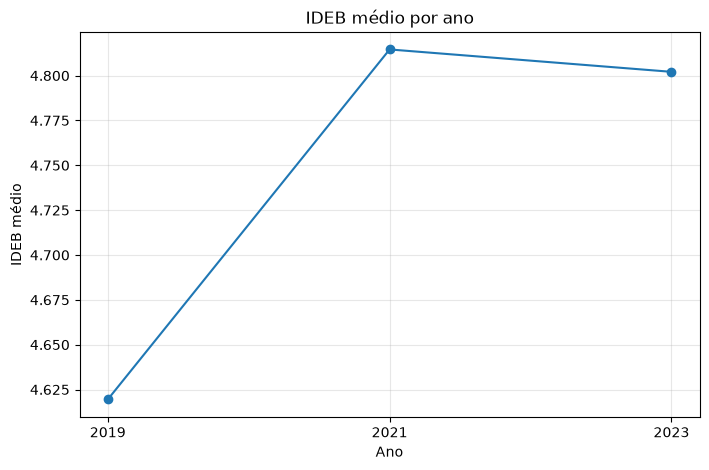

In [26]:
plt.figure(figsize=(8, 5))
plt.plot(
    ideb_por_ano["ano"],
    ideb_por_ano["mean"],
    marker="o"
)
plt.xlabel("Ano")
plt.ylabel("IDEB médio")
plt.title("IDEB médio por ano")
plt.xticks(ideb_por_ano["ano"])
plt.grid(alpha=0.3)
plt.show()


## 17. IDEB por etapa de ensino


In [27]:
ideb_por_etapa = (
    ideb
    .groupby("anos_escolares")["ideb"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .sort_values("mean", ascending=False)
)

display(ideb_por_etapa)


,count,mean,median,std,min,max
anos_escolares,,,,,,
iniciais (1-5),40286,5.13,5.00,1.13,0.70,10.00
finais (6-9),28943,4.43,4.40,0.96,0.80,9.30
todos (1-4),10145,4.06,4.00,0.77,1.30,7.70


## 18. Distribuição geral do IDEB


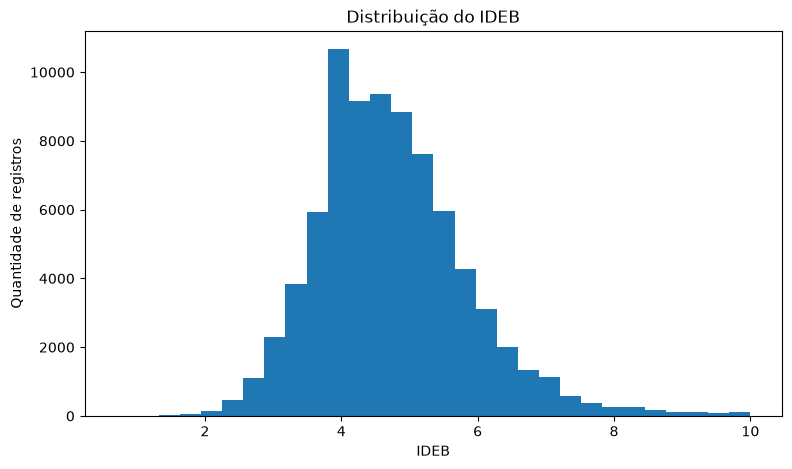

In [28]:
plt.figure(figsize=(9, 5))
plt.hist(ideb["ideb"].dropna(), bins=30)
plt.xlabel("IDEB")
plt.ylabel("Quantidade de registros")
plt.title("Distribuição do IDEB")
plt.show()


# Cruzamento entre Censo Escolar e IDEB


## 19. Validação dos anos e da chave de cruzamento

As duas bases já estão restritas aos anos escolhidos para a amostra: 2019, 2021 e 2023. O cruzamento é realizado pela combinação `ano + id_escola`.

No Censo essa combinação deve ser única. No IDEB, uma mesma escola pode aparecer em mais de uma etapa de ensino, caracterizando um relacionamento muitos-para-um do IDEB para o Censo.


In [29]:
anos_comuns = sorted(
    set(censo["ano"].unique()).intersection(
        set(ideb["ano"].unique())
    )
)

print("Anos comuns:", anos_comuns)

print(
    "Duplicidades ano + id_escola no Censo:",
    censo.duplicated(["ano", "id_escola"]).sum()
)


Anos comuns: [np.int64(2019), np.int64(2021), np.int64(2023)]
Duplicidades ano + id_escola no Censo: 0


## 20. Cruzamento das bases


In [30]:
dados = ideb.merge(
    censo,
    on=["ano", "id_escola"],
    how="left",
    validate="many_to_one",
    indicator=True,
    suffixes=("_ideb", "_censo")
)

print("Dimensão do conjunto integrado:", dados.shape)


Dimensão do conjunto integrado: (79374, 62)


## 21. Qualidade do cruzamento


In [31]:
correspondencia = (
    dados["_merge"]
    .value_counts()
    .rename_axis("resultado")
    .reset_index(name="registros")
)

display(correspondencia)

percentual_correspondencia = (
    (dados["_merge"] == "both").mean() * 100
)

print(f"Correspondência IDEB → Censo: {percentual_correspondencia:.2f}%")


,resultado,registros
0,both,79374
1,left_only,0
2,right_only,0


Correspondência IDEB → Censo: 100.00%


## 22. Correspondência por ano


In [32]:
cruzamento_por_ano = (
    dados
    .groupby("ano")
    .agg(
        registros_ideb=("id_escola", "size"),
        escolas_distintas=("id_escola", "nunique"),
        encontrados=("_merge", lambda x: (x == "both").sum())
    )
    .reset_index()
)

cruzamento_por_ano["percentual_encontrado"] = (
    cruzamento_por_ano["encontrados"] /
    cruzamento_por_ano["registros_ideb"] * 100
)

display(cruzamento_por_ano)


,ano,registros_ideb,escolas_distintas,encontrados,percentual_encontrado
0,2019,28656,22312,28656,100.00
1,2021,21910,17472,21910,100.00
2,2023,28808,22541,28808,100.00


## 23. Dimensão final do conjunto integrado


In [33]:
print(f"Observações escola-etapa-ano: {len(dados):,}")

escola_ano = (
    dados[["ano", "id_escola"]]
    .drop_duplicates()
    .shape[0]
)

print(f"Combinações únicas escola-ano: {escola_ano:,}")
print(f"Escolas distintas no conjunto integrado: {dados['id_escola'].nunique():,}")


Observações escola-etapa-ano: 79,374
Combinações únicas escola-ano: 62,325
Escolas distintas no conjunto integrado: 26,233


## 24. Estatísticas do IDEB após o cruzamento


In [34]:
display(dados["ideb"].describe().to_frame("ideb"))


,ideb
count,79374.00
mean,4.74
std,1.11
min,0.70
25%,4.00
50%,4.60
75%,5.40
max,10.00


## 25. IDEB por ano no conjunto integrado


In [35]:
ideb_cruzado_ano = (
    dados
    .groupby("ano")["ideb"]
    .agg(["count", "mean", "median", "std"])
    .reset_index()
)

display(ideb_cruzado_ano)


,ano,count,mean,median,std
0,2019,28656,4.62,4.50,1.12
1,2021,21910,4.81,4.70,1.00
2,2023,28808,4.80,4.70,1.17


## 26. IDEB por etapa no conjunto integrado


In [36]:
ideb_cruzado_etapa = (
    dados
    .groupby("anos_escolares")["ideb"]
    .agg(["count", "mean", "median", "std"])
    .reset_index()
)

display(ideb_cruzado_etapa)


,anos_escolares,count,mean,median,std
0,finais (6-9),28943,4.43,4.40,0.96
1,iniciais (1-5),40286,5.13,5.00,1.13
2,todos (1-4),10145,4.06,4.00,0.77


## 27. IDEB por rede administrativa


In [37]:
ideb_rede = (
    dados
    .groupby("rede")["ideb"]
    .agg(["count", "mean", "median", "std"])
    .sort_values("mean", ascending=False)
)

display(ideb_rede)


,count,mean,median,std
rede,,,,
Federal,146,5.39,5.20,1.03
Municipal,63722,4.86,4.80,1.13
Estadual,15506,4.24,4.20,0.85


## 28. IDEB por localização


In [38]:
ideb_localizacao = (
    dados
    .groupby("tipo_localizacao")["ideb"]
    .agg(["count", "mean", "median", "std"])
    .sort_values("mean", ascending=False)
)

display(ideb_localizacao)


,count,mean,median,std
tipo_localizacao,,,,
Urbana,48004,4.81,4.70,1.05
Rural,31370,4.64,4.50,1.19


## 29. Características de infraestrutura

O percentual de presença é calculado apenas entre registros válidos. Isso é importante porque algumas variáveis possuem valores ausentes.


In [39]:
variaveis_infraestrutura = [
    "agua_potavel",
    "agua_rede_publica",
    "energia_rede_publica",
    "esgoto_rede_publica",
    "lixo_servico_coleta",
    "area_verde",
    "banheiro_chuveiro",
    "biblioteca",
    "cozinha",
    "laboratorio_ciencias",
    "laboratorio_informatica",
    "quadra_esportes",
    "refeitorio",
    "sala_leitura",
    "desktop_aluno",
    "internet_alunos"
]

percentuais = []

for coluna in variaveis_infraestrutura:
    if coluna in dados.columns:
        serie = dados[coluna].dropna()

        percentuais.append({
            "variavel": coluna,
            "registros_validos": len(serie),
            "percentual_presenca": (
                serie.mean() * 100 if len(serie) > 0 else np.nan
            )
        })

infraestrutura_df = pd.DataFrame(percentuais)

display(
    infraestrutura_df.sort_values(
        "percentual_presenca",
        ascending=False
    )
)


,variavel,registros_validos,percentual_presenca
2,energia_rede_publica,79374,99.87
8,cozinha,79374,98.42
0,agua_potavel,79374,95.19
4,lixo_servico_coleta,79374,85.50
1,agua_rede_publica,79374,77.35
14,desktop_aluno,79374,46.88
6,banheiro_chuveiro,79374,42.43
7,biblioteca,79374,41.10
11,quadra_esportes,79374,39.82
15,internet_alunos,79374,37.71


## 30. IDEB médio segundo características de infraestrutura

Esta comparação é exploratória. Diferenças de média não devem ser interpretadas como relações de causa e efeito, pois outras características da escola podem influenciar simultaneamente o IDEB e a presença desses recursos.


In [40]:
variaveis_comparacao = [
    "biblioteca",
    "laboratorio_ciencias",
    "laboratorio_informatica",
    "quadra_esportes",
    "internet_alunos",
    "agua_potavel"
]

resultados = []

for coluna in variaveis_comparacao:
    if coluna in dados.columns:
        tabela = (
            dados
            .dropna(subset=[coluna])
            .groupby(coluna)["ideb"]
            .agg(["count", "mean", "median"])
            .reset_index()
        )

        tabela["variavel"] = coluna
        resultados.append(tabela)

if resultados:
    comparacao_infraestrutura = pd.concat(
        resultados,
        ignore_index=True
    )

    display(comparacao_infraestrutura)


,biblioteca,count,mean,median,variavel,laboratorio_ciencias,laboratorio_informatica,quadra_esportes,internet_alunos,agua_potavel
0,0.00,46751,4.77,4.70,biblioteca,NaN,NaN,NaN,NaN,NaN
1,1.00,32623,4.70,4.60,biblioteca,NaN,NaN,NaN,NaN,NaN
2,NaN,71256,4.76,4.70,laboratorio_ciencias,0.00,NaN,NaN,NaN,NaN
3,NaN,8118,4.56,4.40,laboratorio_ciencias,1.00,NaN,NaN,NaN,NaN
4,NaN,50884,4.74,4.60,laboratorio_informatica,NaN,0.00,NaN,NaN,NaN
5,NaN,28490,4.75,4.60,laboratorio_informatica,NaN,1.00,NaN,NaN,NaN
6,NaN,47768,4.68,4.60,quadra_esportes,NaN,NaN,0.00,NaN,NaN
7,NaN,31606,4.82,4.70,quadra_esportes,NaN,NaN,1.00,NaN,NaN
8,NaN,49443,4.72,4.60,internet_alunos,NaN,NaN,NaN,0.00,NaN
9,NaN,29931,4.78,4.70,internet_alunos,NaN,NaN,NaN,1.00,NaN


## 31. Construção de variáveis relacionadas às matrículas

Valores absolutos são influenciados pelo tamanho da escola. Por isso, são criadas medidas proporcionais para permitir comparações entre escolas de portes diferentes.


In [41]:
dados["total_matriculas_sexo"] = (
    dados["quantidade_matricula_feminino"].fillna(0) +
    dados["quantidade_matricula_masculino"].fillna(0) +
    dados["quantidade_matricula_nao_declarada"].fillna(0)
)

dados["proporcao_feminino"] = np.where(
    dados["total_matriculas_sexo"] > 0,
    dados["quantidade_matricula_feminino"] /
    dados["total_matriculas_sexo"],
    np.nan
)

display(
    dados[
        [
            "total_matriculas_sexo",
            "proporcao_feminino"
        ]
    ].describe().T
)


,count,mean,std,min,25%,50%,75%,max
total_matriculas_sexo,79374.00,484.15,369.94,10.00,233.00,377.00,618.00,4430.00
proporcao_feminino,79374.00,0.39,0.08,0.00,0.33,0.40,0.45,0.87


## 32. Composição racial das matrículas


In [42]:
colunas_raca = [
    "quantidade_matricula_branca",
    "quantidade_matricula_preta",
    "quantidade_matricula_parda",
    "quantidade_matricula_amarela",
    "quantidade_matricula_indigena"
]

dados["total_matriculas_raca"] = (
    dados[colunas_raca]
    .fillna(0)
    .sum(axis=1)
)

for coluna in colunas_raca:
    nome = coluna.replace(
        "quantidade_matricula_",
        "proporcao_"
    )

    dados[nome] = np.where(
        dados["total_matriculas_raca"] > 0,
        dados[coluna] / dados["total_matriculas_raca"],
        np.nan
    )

colunas_proporcao_raca = [
    "proporcao_branca",
    "proporcao_preta",
    "proporcao_parda",
    "proporcao_amarela",
    "proporcao_indigena"
]

display(dados[colunas_proporcao_raca].describe().T)


,count,mean,std,min,25%,50%,75%,max
proporcao_branca,79335.00,0.17,0.13,0.00,0.07,0.14,0.23,1.00
proporcao_preta,79335.00,0.05,0.08,0.00,0.01,0.03,0.06,1.00
proporcao_parda,79335.00,0.77,0.15,0.00,0.69,0.79,0.88,1.00
proporcao_amarela,79335.00,0.01,0.03,0.00,0.00,0.00,0.01,0.89
proporcao_indigena,79335.00,0.01,0.06,0.00,0.00,0.00,0.00,1.00


## 33. Correlações exploratórias

As correlações servem como uma primeira medida de associação linear. Elas não representam causalidade e devem ser interpretadas junto com variáveis de controle como ano, rede administrativa, localização e etapa de ensino.


In [43]:
variaveis_correlacao = [
    "ideb",
    "quantidade_sala_utilizada_climatizada",
    "quantidade_profissional_saude",
    "quantidade_profissional_nutricionista",
    "quantidade_profissional_psicologo",
    "quantidade_profissional_pedagogia",
    "total_matriculas_sexo",
    "proporcao_feminino",
    "proporcao_branca",
    "proporcao_preta",
    "proporcao_parda",
    "proporcao_amarela",
    "proporcao_indigena"
]

variaveis_correlacao = [
    coluna
    for coluna in variaveis_correlacao
    if coluna in dados.columns
]

correlacao = dados[variaveis_correlacao].corr(numeric_only=True)

display(correlacao)


,ideb,quantidade_sala_utilizada_climatizada,quantidade_profissional_saude,quantidade_profissional_nutricionista,quantidade_profissional_psicologo,quantidade_profissional_pedagogia,total_matriculas_sexo,proporcao_feminino,proporcao_branca,proporcao_preta,proporcao_parda,proporcao_amarela,proporcao_indigena
ideb,1.00,0.09,0.02,0.00,0.04,0.04,-0.02,0.10,0.16,-0.15,-0.04,-0.04,-0.05
quantidade_sala_utilizada_climatizada,0.09,1.00,0.10,0.03,0.09,0.12,0.29,0.09,0.09,-0.06,-0.04,0.02,-0.02
quantidade_profissional_saude,0.02,0.10,1.00,0.05,0.14,0.09,0.05,0.01,0.02,-0.00,-0.02,0.01,0.00
quantidade_profissional_nutricionista,0.00,0.03,0.05,1.00,0.38,0.05,-0.02,-0.01,0.00,0.06,-0.03,0.02,-0.02
quantidade_profissional_psicologo,0.04,0.09,0.14,0.38,1.00,0.10,0.06,-0.01,0.04,0.01,-0.04,0.00,-0.01
quantidade_profissional_pedagogia,0.04,0.12,0.09,0.05,0.10,1.00,0.21,0.03,0.04,-0.03,-0.02,-0.00,-0.00
total_matriculas_sexo,-0.02,0.29,0.05,-0.02,0.06,0.21,1.00,-0.13,0.02,0.01,-0.01,-0.01,-0.03
proporcao_feminino,0.10,0.09,0.01,-0.01,-0.01,0.03,-0.13,1.00,-0.03,-0.03,0.02,0.04,0.03
proporcao_branca,0.16,0.09,0.02,0.00,0.04,0.04,0.02,-0.03,1.00,-0.17,-0.75,-0.02,-0.08
proporcao_preta,-0.15,-0.06,-0.00,0.06,0.01,-0.03,0.01,-0.03,-0.17,1.00,-0.35,0.03,-0.04


# Síntese da análise exploratória

As duas bases utilizadas nesta versão já estão delimitadas aos anos de **2019, 2021 e 2023**, definidos como amostra inicial do projeto. Esse recorte permite trabalhar com um conjunto mais recente de variáveis do Censo Escolar e mantém compatibilidade temporal direta com as edições do IDEB.

O Censo Escolar utiliza `ano + id_escola` como chave de identificação de uma escola em um determinado ano. Na tabela do IDEB, a mesma escola pode apresentar mais de um registro no ano em razão das diferentes etapas avaliadas, sendo `ano + id_escola + anos_escolares` a combinação adequada para identificar cada observação do indicador.

A avaliação de valores ausentes deve considerar tanto o percentual global quanto sua distribuição por ano. Variáveis com grande quantidade de ausências ou códigos especiais precisam ser tratadas antes de análises estatísticas e modelagem.

O cruzamento é realizado por `ano + id_escola` em uma relação muitos-para-um do IDEB para o Censo. A qualidade dessa integração é avaliada pelo percentual de registros do IDEB que encontram correspondência no Censo.

As análises de infraestrutura, composição das matrículas e correlações são exploratórias. Diferenças observadas entre grupos não devem ser interpretadas isoladamente como relações causais, pois fatores como ano, estado, rede administrativa, localização, etapa de ensino e tamanho da escola podem atuar simultaneamente sobre o desempenho educacional.
